In [53]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [54]:
# Conversion factor: 1 THz = 33.35641 cm^-1
CM_TO_THZ = 1.0 / 33.35641

k_ticks = [0.000000, 0.677895, 1.016842, 1.603975, 1.919521]
k_labels = ['Γ', 'K', 'M', 'Γ', 'A']

try:
    data = np.loadtxt('ZnO222.bands')
except IOError:
    print("Error: 'ZnO222.bands' file not found.")
    exit()


In [55]:

k_distance = data[:, 0]

eigenvalues_cm = data[:, 1:]

eigenvalues_thz = eigenvalues_cm * CM_TO_THZ


In [56]:
# 1a linha -> eigenvalues_cm[0]
eigenvalues_cm[0]

array([1.097373e-10, 1.097373e-10, 1.097373e-10, 8.957866e+01,
       8.957870e+01, 2.464182e+02, 3.527109e+02, 3.736413e+02,
       3.736415e+02, 4.046092e+02, 4.046094e+02, 5.166929e+02])

In [57]:
! grep -A1 "# k-axis" 'ZnO222.bands'

# k-axis, Eigenvalues [cm^-1]
0.000000   1.097373e-10   1.097373e-10   1.097373e-10   8.957866e+01   8.957870e+01   2.464182e+02   3.527109e+02   3.736413e+02   3.736415e+02   4.046092e+02   4.046094e+02   5.166929e+02


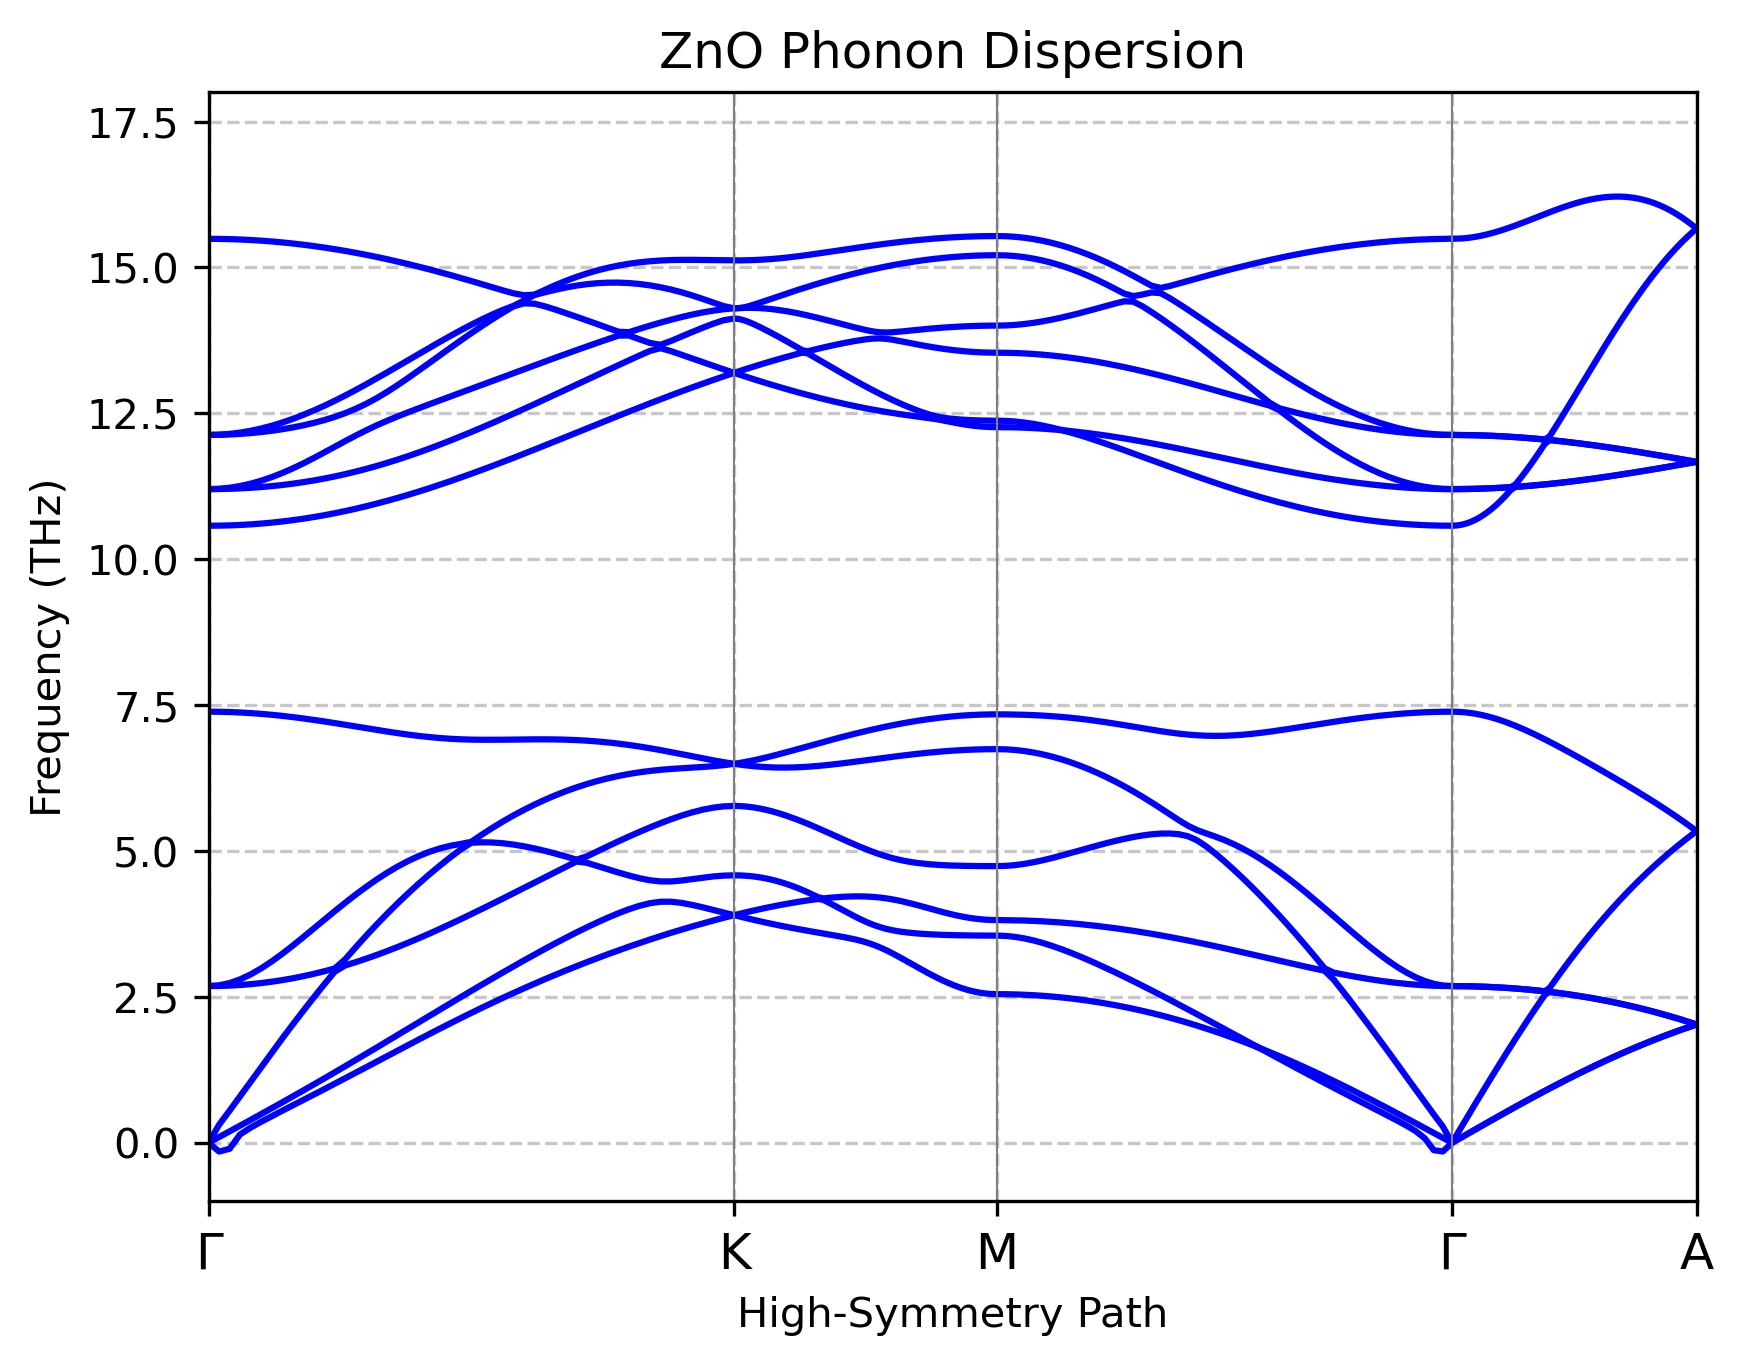

<Figure size 800x600 with 0 Axes>

In [58]:
fig, ax = plt.subplots(dpi=300)
plt.figure(figsize=(8, 6))

num_bands = eigenvalues_thz.shape[1]

# uma linha uma banda
for i in range(num_bands):
    ax.plot(k_distance, eigenvalues_thz[:, i], '-b')

ax.set_title('ZnO Phonon Dispersion')
ax.set_xlabel('High-Symmetry Path')
ax.set_ylabel('Frequency (THz)')

ax.set_xticks(k_ticks, k_labels, fontsize=12)
ax.set_xlim(k_ticks[0], k_ticks[-1])

ax.set_ylim(-1, 18)

ax.grid(True, linestyle='--', alpha=0.7)

for tick in k_ticks:
    ax.axvline(x=tick, color='grey', linestyle='-', linewidth=0.5)

#plt.savefig('ZnO_phonons_corrected.png', dpi=300)

plt.show()

<h1> Experimental Data </h1>

Experimental Data Extracted from Ref:

> _"Wu, X. et al. Thermal Conductivity of Wurtzite Zinc-Oxide from First-Principles Lattice Dynamics - a Comparative Study with Gallium Nitride. Sci. Rep. 6, 22504; doi: 10.1038/srep22504 (2016)."_
 
 which uses experimental data from:

> 54. Serrano, J. et al. Phonon dispersion relations of zinc oxide: Inelastic neutron scattering and\textitab initio calculations. Phys.Rev.B 81, 174304 (2010).
> 55. Hewat, A. W. Lattice dynamics of ZnO and BeO. Solid State Commun. 8, 187–189 (1970).
> 56. Thoma, K., Dorner, B., Duesing, G. & Wegener, W. Lattice dynamics of ZnO. Solid State Commun. 15, 1111–1114 (1974).
> 57. Serrano, J. et al. Dependence of phonon widths on pressure and isotopic mass: ZnO. Phys status solidi (b) 235, 260–266 (2003).

In [76]:
# Loading Experimental Data
exp_data_red = pd.read_csv('ZnO_Phonon_Ref_RedTriangles.txt', sep=';', header=2)
exp_data_purple = pd.read_csv('ZnO_Phonons_Ref_PurpleCircles.txt', sep=';', header=2)
exp_data_blue = pd.read_csv('ZnO_Phonons_Ref_BlueSquares.txt', sep=';', header=2)

In [81]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=1200)


num_bands = eigenvalues_thz.shape[1]
# ERROR ~ 0.8 Thz

# uma linha uma banda
for i in range(num_bands):
    
    if i == num_bands-1:
        ax.plot(k_distance, eigenvalues_thz[:, i], '-k', label='ALAMODE')
    else:
        ax.plot(k_distance, eigenvalues_thz[:, i], '-k')

ax.set_title('ZnO Phonon Dispersion')
ax.set_xlabel('High-Symmetry Path')
ax.set_ylabel('Frequency (THz)')

ax.set_xticks(k_ticks, k_labels, fontsize=12)
ax.set_xlim(k_ticks[0], k_ticks[-1])

ax.set_ylim(-1, 18)

ax.grid(True, linestyle='--', alpha=0.7)

for tick in k_ticks:
    ax.axvline(x=tick, color='grey', linestyle='-', linewidth=0.5)

# Experimental Data
ax.scatter(
    x=exp_data_red['k'],
    y=exp_data_red['Freq_THz'],
    s=4,
    marker='^',
    color='red',
    label='Exp. Data (Ref 54)'
)
ax.scatter(
    x=exp_data_purple['k'],
    y=exp_data_purple['Freq_THz'],
    s=4,
    marker='o',
    color='magenta',
    label='Exp. Data (Ref 55, 56)'
)

ax.scatter(
    x=exp_data_blue['k'],
    y=exp_data_blue['Freq_THz'],
    s=4,
    marker='s',
    color='blue',
    label='Exp. Data (Ref 57)'
)
#plt.savefig('ZnO_phonons_corrected.png', dpi=300)
ax.legend()
plt.show()

<div align="center">     
Por quê não usou LDA?
</div>     


Acontecendo LO-TO splitting ???

LO-TO splitting: correção necessária __caso esteja acontecendo__ => Consultar o Von.
